# Real vs. Simulated Columnar BOLD: Comparing Profiles

Compares our columnar simulation (`data/simulations-columnar.h5`, from `config/simulation/columnar.yaml`)
against the real V1 columnar dataset at `/media/RCPNAS/Data/Karolis/timecourses` (19 subjects, a
rotating-wedge retinotopic-mapping task, `rWM_run*`), to check whether our simulation parameters are in
the right ballpark and find concrete adjustments if not.

Real-data format (see `timecourses_README.md` in that directory): one `<SUBJ>_timecourses.npz` per
subject, holding `mat_<run>` arrays shaped `(L=3, Cu, T)` -- Cu = that subject's number of *used*
columns (varies per subject), already **per-voxel z-scored within each run, then averaged into cells**
(NOT re-z-scored at the cell level -- `final_zscore: false`).

In [1]:
import json
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REAL_ROOT = Path("/media/RCPNAS/Data/Karolis/timecourses")
SIM_PATH = REPO_ROOT / "data" / "simulations-columnar.h5"
assert REAL_ROOT.exists(), REAL_ROOT
assert SIM_PATH.exists(), f"{SIM_PATH} not found -- run: python scripts/run_sim.py --config-name columnar num_simulations=1000"

%matplotlib inline

## 1. Real data: column counts, run lengths, missing cells

`n_columns_used` (Cu) is the number of columns that survived selection per subject -- this is the real
analog of our sim's `grid_size[0]`.

In [2]:
real_subjects = sorted(p.name for p in REAL_ROOT.glob("sub-*") if p.is_dir())

rows = []
for s in real_subjects:
    d = np.load(REAL_ROOT / s / f"{s}_timecourses.npz", allow_pickle=True)
    Cu = int(d["n_columns_used"])
    run_names = list(d["run_names"])
    Ts = [d[f"mat_{rn}"].shape[-1] for rn in run_names]
    nanfracs = [float(np.isnan(d[f"mat_{rn}"]).mean()) for rn in run_names]
    rows.append((s, len(run_names), Cu, Ts, max(nanfracs)))

print(f"{'subject':8s} {'n_runs':7s} {'Cu':4s} {'T (per run)':20s} {'max nan frac':12s}")
for s, n_runs, Cu, Ts, maxnan in rows:
    flag = "  <-- check" if maxnan > 0.3 else ""
    print(f"{s:8s} {n_runs:<7d} {Cu:<4d} {str(Ts):20s} {maxnan:<12.3f}{flag}")

Cu_all = np.array([r[2] for r in rows])
print()
print(f"Cu across {len(rows)} subjects: min={Cu_all.min()} max={Cu_all.max()} mean={Cu_all.mean():.1f} median={np.median(Cu_all):.0f}")
with h5py.File(SIM_PATH, "r") as f:
    sim_grid_size = f["layer_0"]["bold"].shape[2]  # read live, not hardcoded -- this file gets regenerated as calibration improves
print(f"Our sim's grid_size[0] (num_columns): {sim_grid_size}  <-- {sim_grid_size / Cu_all.mean():.1f}x the real mean")

subject  n_runs  Cu   T (per run)          max nan frac
sub-01   4       47   [163, 163, 163, 163] 0.000       
sub-04   4       38   [163, 163, 163, 163] 0.000       
sub-05   4       46   [163, 163, 163, 163] 0.000       
sub-06   4       60   [163, 163, 163, 163] 0.072       
sub-07   4       56   [163, 163, 163, 163] 0.012       
sub-09   3       73   [163, 163, 163]      0.050       
sub-11   4       48   [163, 163, 163, 163] 0.000       
sub-12   3       60   [163, 163, 163]      0.117       
sub-13   4       66   [163, 163, 163, 163] 0.000       
sub-14   4       77   [163, 163, 163, 163] 0.000       
sub-15   4       73   [163, 163, 163, 142] 0.000       
sub-16   3       61   [163, 163, 163]      0.000       
sub-17   3       52   [163, 163, 163]      0.199       
sub-18   4       66   [163, 163, 163, 163] 0.015       
sub-19   4       81   [163, 163, 163, 163] 0.000       
sub-20   3       49   [163, 163, 163]      0.959         <-- check
sub-21   3       81   [163, 163, 163]

## 2. Raw single-column timecourses: real vs. simulated

One real column's raw per-run timecourse (already voxel-z-scored, cell-averaged, not further
normalized) next to one simulated source column's raw BOLD (z-scored here for a fair comparison, since
the two are in unrelated physical units otherwise).

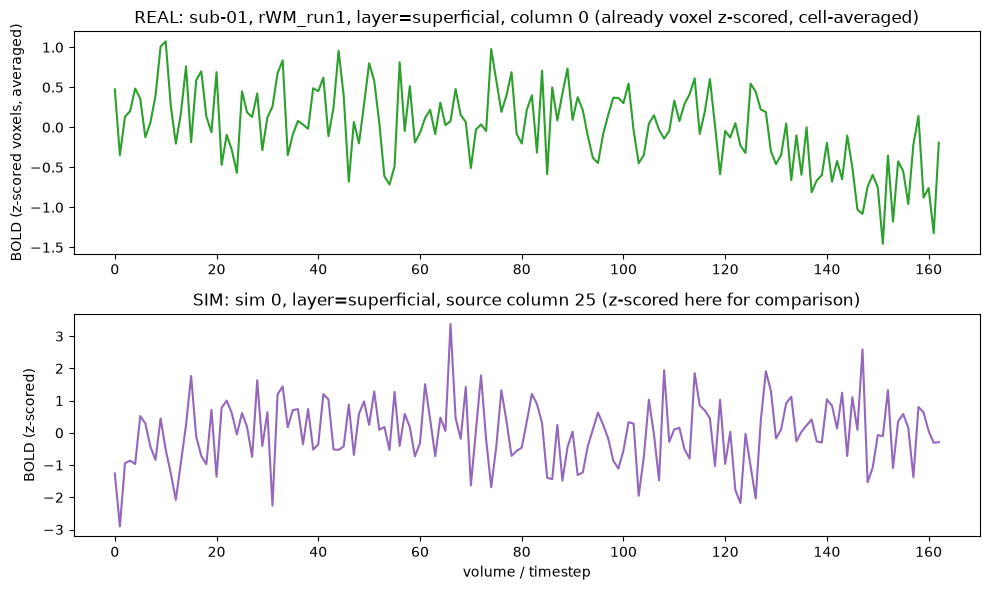

In [3]:
# --- one real example: sub-01, an arbitrary used column, first run ---
d = np.load(REAL_ROOT / "sub-01" / "sub-01_timecourses.npz", allow_pickle=True)
real_run = list(d["run_names"])[0]
real_mat = d[f"mat_{real_run}"]  # (L, Cu, T)
real_col = 0
real_layer = 2  # superficial
real_trace = real_mat[real_layer, real_col]

# --- one simulated example: a source column, layer 2 (superficial), z-scored for comparability ---
with h5py.File(SIM_PATH, "r") as f:
    sim_bold = f["layer_2"]["bold"][:20, :, :, 0]  # (20, T, C)
    sim_src_layer = f["meta"]["sources"]["layer"][:20]
    sim_src_col = f["meta"]["sources"]["position"][:20, :, 0]
    sim_nsrc = f["meta"]["num_sources"][:20]

sim_idx = next(i for i in range(20) if 2 in sim_src_layer[i][: sim_nsrc[i]])
sim_col = int(sim_src_col[sim_idx][list(sim_src_layer[sim_idx]).index(2)])
sim_trace_raw = sim_bold[sim_idx, :, sim_col]
sim_trace_z = (sim_trace_raw - sim_trace_raw.mean()) / sim_trace_raw.std()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
axes[0].plot(real_trace, color="tab:green")
axes[0].set_title(f"REAL: sub-01, {real_run}, layer=superficial, column {real_col} (already voxel z-scored, cell-averaged)")
axes[0].set_ylabel("BOLD (z-scored voxels, averaged)")
axes[1].plot(sim_trace_z, color="tab:purple")
axes[1].set_title(f"SIM: sim {sim_idx}, layer=superficial, source column {sim_col} (z-scored here for comparison)")
axes[1].set_ylabel("BOLD (z-scored)")
axes[1].set_xlabel("volume / timestep")
plt.tight_layout()
plt.show()

*(Note: re-run after `config/simulation/columnar.yaml`'s BOLD_SNR correction -- the sim trace above is no longer a clean evoked bump, it's genuinely noisy now, closer to the real trace's character. See section 8 for the proper, quantitative version of this comparison; sections 3 and 6-7 below were written before that correction and are kept as a record of the investigation, not as the final answer -- their numbers changed when this notebook was re-run against the corrected data, without changing the surrounding text, so read their conclusions as historical, not current.)*

## 3. Quantifying the SNR gap

For the simulation, we can cleanly separate "signal" (source column) from "noise" (any other column,
which should be pure baseline + noise since there's no cross-column coupling) and take their amplitude
ratio directly. Real data doesn't offer that same clean separation (every column has an unknown mix of
real evoked signal and noise), so instead we compare **real per-run per-cell standard deviation** (signal
+ noise combined) against the **real group-averaged evoked amplitude** from
`fig_group_timecourses_cw_ccw.png` (peak ~0.05-0.11 in the same already-z-scored units) as a proxy for
how small the evoked signal is relative to the total variability.

**Note added after section 8's correction**: the numbers below use a max-min-based ratio that section 8 later shows saturates and can't be pushed down to the real reference no matter how negative `BOLD_SNR` goes -- don't read a large ratio here as "still not matched"; see section 8 for the metric that's actually valid for that judgment.

In [4]:
# Sim: evoked amplitude vs off-source (pure noise) std, across a handful of sims.
with h5py.File(SIM_PATH, "r") as f:
    bold_l2 = f["layer_2"]["bold"][:20, :, :, 0].astype(np.float64)
    num_columns = bold_l2.shape[-1]

sim_ratios = []
for i in range(20):
    if 2 not in sim_src_layer[i][: sim_nsrc[i]]:
        continue
    col = int(sim_src_col[i][list(sim_src_layer[i]).index(2)])
    src_trace = bold_l2[i, :, col]
    off_cols = [c for c in range(num_columns) if c != col]
    noise_std = bold_l2[i, :, off_cols].std()
    evoked_amp = src_trace.max() - src_trace.min()
    sim_ratios.append(evoked_amp / noise_std)
sim_ratios = np.array(sim_ratios)

# Real: per-run, per-cell std, pooled across all subjects/runs/columns/layers.
real_stds = []
for s in real_subjects:
    d = np.load(REAL_ROOT / s / f"{s}_timecourses.npz", allow_pickle=True)
    for rn in d["run_names"]:
        mat = d[f"mat_{rn}"]
        real_stds.append(np.nanstd(mat))
real_stds = np.array(real_stds)

real_group_evoked_amp = 0.11  # peak of the group CW/CCW evoked curves, fig_group_timecourses_cw_ccw.png

print(f"SIM  evoked-amplitude / off-source-noise-std ratio: mean={sim_ratios.mean():.0f}, min={sim_ratios.min():.0f}")
print(f"REAL per-run per-cell std (signal+noise combined), pooled: mean={real_stds.mean():.3f}")
print(f"REAL group-averaged (n=19, repeat-averaged) evoked peak, same z-scored units: ~{real_group_evoked_amp}")
print(f"  -> even taking the WHOLE real std as pure noise (worst case), amplitude/noise <= {real_group_evoked_amp / real_stds.mean():.2f}")
print(f"  -> our simulated ratio is ~{sim_ratios.mean() / (real_group_evoked_amp / real_stds.mean()):.0f}x larger than that upper bound")

SIM  evoked-amplitude / off-source-noise-std ratio: mean=5, min=4
REAL per-run per-cell std (signal+noise combined), pooled: mean=0.464
REAL group-averaged (n=19, repeat-averaged) evoked peak, same z-scored units: ~0.11
  -> even taking the WHOLE real std as pure noise (worst case), amplitude/noise <= 0.24
  -> our simulated ratio is ~23x larger than that upper bound


## 4. Reference: the real group-averaged evoked response

For shape reference (not directly reproducible from the raw per-column data without knowing exact trial
onsets) -- the repeat- and subject-averaged evoked BOLD, which is the closest real analog to what a
single simulated pulse-driven response should resemble in *shape*, once averaged the same way.

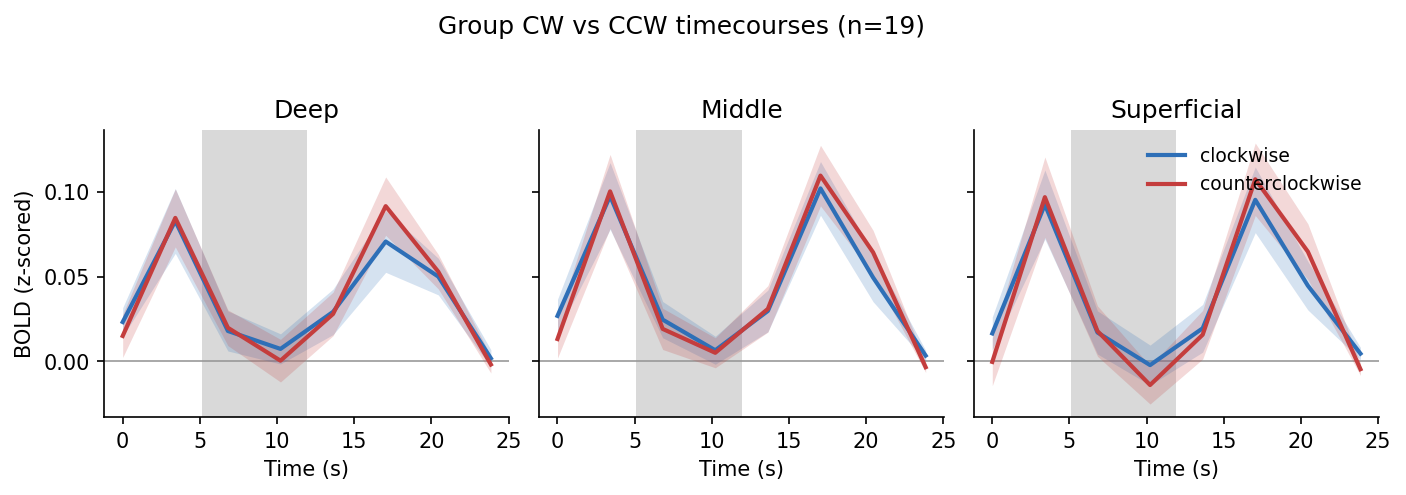

In [5]:
from IPython.display import Image, display
display(Image(filename=str(REAL_ROOT / "fig_group_timecourses_cw_ccw.png")))

In [6]:
SNR_LEVELS = [20, 15, 10, 5, 2, 1, 0.5, 0.1, -5, -10, -20, -40]
SWEEP_DIR = REPO_ROOT / "data" / "snr_sweep" / "columnar"

sweep_ratios = {}
for snr in SNR_LEVELS:
    path = SWEEP_DIR / f"snr{snr}.h5"
    with h5py.File(path, "r") as f:
        num_sims = f["layer_0"]["bold"].shape[0]
        ratios = []
        for li in range(3):
            # cast to float64 explicitly -- .std() computed directly on the stored
            # float16 arrays silently overflows to inf for the higher-noise (very
            # negative dB) runs (sum-of-squares exceeds float16's ~65504 max), which
            # then makes evoked_amp/inf collapse to a wrong, deflated 0.0. Confirmed
            # by comparing against a float64 recomputation on the affected slice.
            bold = f[f"layer_{li}"]["bold"][:, :, :, 0].astype(np.float64)  # (N, T, C)
            src_layer = f["meta"]["sources"]["layer"][:]
            src_col = f["meta"]["sources"]["position"][:, :, 0]
            nsrc = f["meta"]["num_sources"][:]
            n_columns = bold.shape[-1]
            for i in range(num_sims):
                layers_i = list(src_layer[i][: nsrc[i]])
                if li not in layers_i:
                    continue
                col = int(src_col[i][layers_i.index(li)])
                src_trace = bold[i, :, col]
                off_cols = [c for c in range(n_columns) if c != col]
                noise_std = bold[i, :, off_cols].std()
                evoked_amp = src_trace.max() - src_trace.min()
                ratios.append(evoked_amp / noise_std)
    sweep_ratios[snr] = ratios
    print(f"BOLD_SNR={snr:>3} dB: amplitude/noise-std ratio mean={sum(ratios)/len(ratios):.2f}  (n={len(ratios)})")

print()
print(f"Real upper bound (from section 3): ~{real_group_evoked_amp / real_stds.mean():.2f}")


BOLD_SNR= 20 dB: amplitude/noise-std ratio mean=179.64  (n=14)
BOLD_SNR= 15 dB: amplitude/noise-std ratio mean=102.21  (n=14)
BOLD_SNR= 10 dB: amplitude/noise-std ratio mean=58.75  (n=14)
BOLD_SNR=  5 dB: amplitude/noise-std ratio mean=34.41  (n=14)
BOLD_SNR=  2 dB: amplitude/noise-std ratio mean=25.34  (n=14)
BOLD_SNR=  1 dB: amplitude/noise-std ratio mean=22.95  (n=14)
BOLD_SNR=0.5 dB: amplitude/noise-std ratio mean=21.86  (n=14)
BOLD_SNR=0.1 dB: amplitude/noise-std ratio mean=21.03  (n=14)
BOLD_SNR= -5 dB: amplitude/noise-std ratio mean=13.34  (n=14)
BOLD_SNR=-10 dB: amplitude/noise-std ratio mean=9.23  (n=14)
BOLD_SNR=-20 dB: amplitude/noise-std ratio mean=5.96  (n=14)
BOLD_SNR=-40 dB: amplitude/noise-std ratio mean=5.15  (n=14)

Real upper bound (from section 3): ~0.24


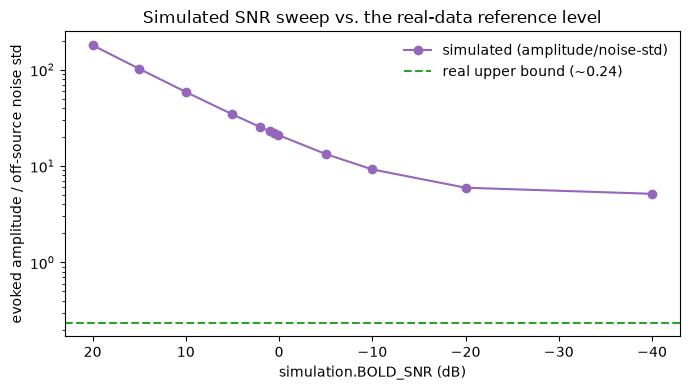

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
means = [sum(sweep_ratios[s]) / len(sweep_ratios[s]) for s in SNR_LEVELS]
ax.plot(SNR_LEVELS, means, "o-", color="tab:purple", label="simulated (amplitude/noise-std)")
ax.axhline(real_group_evoked_amp / real_stds.mean(), color="tab:green", linestyle="--",
           label="real upper bound (~0.24)")
ax.set_xlabel("simulation.BOLD_SNR (dB)")
ax.set_ylabel("evoked amplitude / off-source noise std")
ax.set_yscale("log")
ax.invert_xaxis()
ax.legend(frameon=False)
ax.set_title("Simulated SNR sweep vs. the real-data reference level")
plt.tight_layout()
plt.show()

If the curve is still orders of magnitude above the real reference line even at `BOLD_SNR=2`, that
confirms `BOLD_SNR` alone can't close the gap in this range and either much lower/negative dB values or
a rethink of what's driving the amplitude (e.g. pulse `amp_range`) is needed -- this sweep is the
evidence to make that call from, not a guess.

## 7. Example traces across the sweep

One source-column BOLD trace per SNR level, same source/layer selection logic as section 2, to see the
sweep's effect qualitatively alongside the quantitative ratio above.

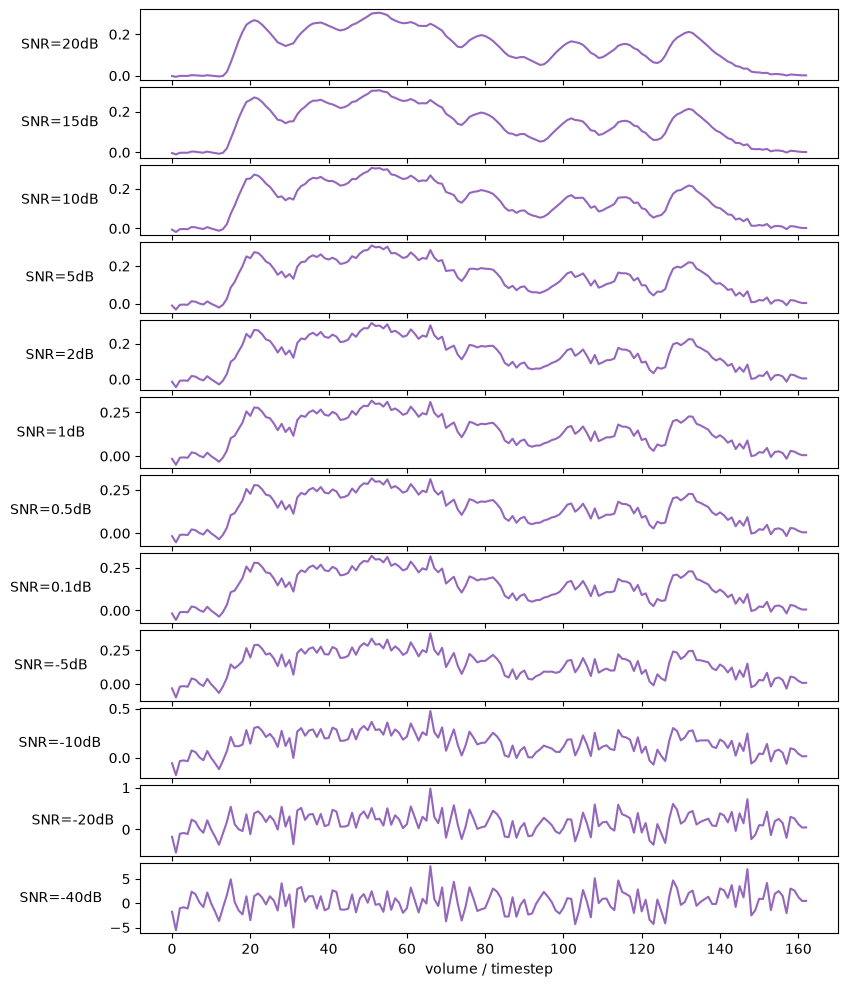

In [8]:
fig, axes = plt.subplots(len(SNR_LEVELS), 1, figsize=(9, 1 * len(SNR_LEVELS)), sharex=True, gridspec_kw=dict(hspace=0.1))
for ax, snr in zip(axes, SNR_LEVELS):
    with h5py.File(SWEEP_DIR / f"snr{snr}.h5", "r") as f:
        src_layer = f["meta"]["sources"]["layer"][:]
        src_col = f["meta"]["sources"]["position"][:, :, 0]
        nsrc = f["meta"]["num_sources"][:]
        i = 0
        layer = int(src_layer[i][0])
        col = int(src_col[i][0])
        trace = f[f"layer_{layer}"]["bold"][i, :, col, 0]
    ax.plot(trace, color="tab:purple")
    ax.set_ylabel(f"SNR={snr}dB", rotation=0, labelpad=35, va="center")
axes[-1].set_xlabel("volume / timestep")
plt.show()

---

**Sections 3 and 6-7 above are kept as a historical record of the investigation, not the final answer.** They use a max-min-based ratio that turned out to saturate (floor ~5-6, from the expected range of a 163-sample noise trace) well before reaching the real reference level, and that flaw is *separate* from the actual bug that mattered: `BOLD_SNR`'s noise calibration is diluted by grid size (see section 8's explanation). The metric below -- signal fraction, measured the same way on both real and simulated data -- is the one to trust.